In [69]:
!pip install albumentations --quiet

In [70]:
"""
=============================================================
  AUGMENTATION + SPLIT DATASET - Biển báo giao thông VN
  YOLOv8 | Kaggle Notebook
=============================================================
CẤU TRÚC INPUT:
  /kaggle/input/DoanAI/Final/
    ├── images/          ← toàn bộ ảnh gốc
    ├── labels/          ← toàn bộ label YOLO tương ứng
    ├── split_dataset/
    │   ├── train_files.txt
    │   ├── valid_files.txt
    │   └── test_files.txt
    └── classes.txt
 
CẤU TRÚC OUTPUT:
  /kaggle/working/dataset_aug/
    ├── images/          ← toàn bộ ảnh (gốc + augmented)
    ├── labels/          ← toàn bộ label tương ứng
    ├── split_dataset/
    │   ├── train_files.txt   ← 80%, đủ 67 classes
    │   ├── valid_files.txt   ← 10%, đủ 67 classes
    │   └── test_files.txt    ← 10%, đủ 67 classes
    └── classes.txt
=============================================================
"""

'\n=============================================================\n  AUGMENTATION + SPLIT DATASET - Biển báo giao thông VN\n  YOLOv8 | Kaggle Notebook\n=============================================================\nCẤU TRÚC INPUT:\n  /kaggle/input/DoanAI/Final/\n    ├── images/          ← toàn bộ ảnh gốc\n    ├── labels/          ← toàn bộ label YOLO tương ứng\n    ├── split_dataset/\n    │   ├── train_files.txt\n    │   ├── valid_files.txt\n    │   └── test_files.txt\n    └── classes.txt\n \nCẤU TRÚC OUTPUT:\n  /kaggle/working/dataset_aug/\n    ├── images/          ← toàn bộ ảnh (gốc + augmented)\n    ├── labels/          ← toàn bộ label tương ứng\n    ├── split_dataset/\n    │   ├── train_files.txt   ← 80%, đủ 67 classes\n    │   ├── valid_files.txt   ← 10%, đủ 67 classes\n    │   └── test_files.txt    ← 10%, đủ 67 classes\n    └── classes.txt\n=============================================================\n'

In [71]:
import os, cv2, random, shutil
import numpy as np
import albumentations as A
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
 
# ─────────────────────────────────────────────
#  CẤU HÌNH
# ─────────────────────────────────────────────
INPUT_BASE   = "/kaggle/input/datasets/giahuy038/doanai/Final"
OUTPUT_BASE  = "/kaggle/working/DoanAi_aug"
 
NUM_CLASSES          = 67    # tổng số class
MIN_IMAGES_PER_CLASS = 80    # class < ngưỡng này → augment
AUG_MULTIPLIER       = 6     # mỗi ảnh gốc sinh N ảnh aug
TARGET_PER_CLASS     = 150   # mục tiêu tối thiểu mỗi class sau aug
 
SPLIT_RATIO          = (0.80, 0.10, 0.10)   # train : valid : test
MIN_PER_CLASS_SPLIT  = 10     # tối thiểu N ảnh/class trong valid & test
 
SEED = 42
# ─────────────────────────────────────────────
 

random.seed(SEED)
np.random.seed(SEED)
 
SRC_IMG_DIR   = Path(INPUT_BASE) / "images"
SRC_LBL_DIR   = Path(INPUT_BASE) / "labels"
SRC_CLASSES   = Path(INPUT_BASE) / "classes.txt"
 
OUT_IMG_DIR   = Path(OUTPUT_BASE) / "images"
OUT_LBL_DIR   = Path(OUTPUT_BASE) / "labels"
OUT_SPLIT_DIR = Path(OUTPUT_BASE) / "split_dataset"
 
OUT_IMG_DIR.mkdir(parents=True, exist_ok=True)
OUT_LBL_DIR.mkdir(parents=True, exist_ok=True)
OUT_SPLIT_DIR.mkdir(parents=True, exist_ok=True)

In [72]:
# ════════════════════════════════════════════════════════════
# 1. AUGMENTATION PIPELINE (tương thích albumentations mới)
# ════════════════════════════════════════════════════════════
 
def build_transform():
    return A.Compose([
        # Hình học
        A.Affine(
            translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
            scale=(0.88, 1.12),
            rotate=(-15, 15),
            p=0.5
        ),
        A.Perspective(scale=(0.02, 0.05), p=0.3),
        A.HorizontalFlip(p=0.2),
 
        # Màu sắc & ánh sáng
        A.RandomBrightnessContrast(brightness_limit=0.35, contrast_limit=0.3, p=0.6),
        A.HueSaturationValue(hue_shift_limit=12, sat_shift_limit=35, val_shift_limit=25, p=0.5),
        A.CLAHE(clip_limit=2.5, p=0.3),
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.3),
 
        # Noise & Blur
        A.OneOf([
            A.GaussNoise(p=1.0),
            A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.4), p=1.0),
            A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1.0),
        ], p=0.35),
        A.OneOf([
            A.MotionBlur(blur_limit=5, p=1.0),
            A.GaussianBlur(blur_limit=3, p=1.0),
        ], p=0.25),
 
        # Thời tiết — dùng tham số mới của albumentations
        A.OneOf([
            A.RandomRain(rain_type="drizzle", p=1.0),
            A.RandomFog(p=1.0),
            A.RandomSunFlare(flare_roi=(0, 0, 1, 0.5), src_radius=100, p=1.0),
        ], p=0.2),
 
        # Che khuất — dùng tên tham số mới
        A.CoarseDropout(
            num_holes_range=(1, 4),
            hole_height_range=(8, 18),
            hole_width_range=(8, 18),
            fill=128,
            p=0.2
        ),
 
    ], bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels'],
        min_visibility=0.35,
        clip=True,
    ))

In [73]:
# ════════════════════════════════════════════════════════════
# 2. UTIL: ĐỌC / GHI LABEL  ← FIX: xử lý class_id dạng float
# ════════════════════════════════════════════════════════════
 
def read_label(lbl_path):
    """→ list of [cls_int, cx, cy, w, h]
    Fix: class_id có thể là '1.0' (float string) → ép sang int
    """
    rows = []
    p = Path(lbl_path)
    if not p.exists():
        return rows
    for line in p.read_text().strip().splitlines():
        parts = line.strip().split()
        if len(parts) == 5:
            try:
                cls = int(float(parts[0]))   # '1.0' → 1.0 → 1
                bbox = list(map(float, parts[1:]))
                rows.append([cls] + bbox)
            except ValueError:
                continue   # bỏ qua dòng lỗi
    return rows
 
 
def write_label(lbl_path, rows):
    with open(lbl_path, 'w') as f:
        for r in rows:
            f.write(f"{int(r[0])} {r[1]:.6f} {r[2]:.6f} {r[3]:.6f} {r[4]:.6f}\n")
 
 
def find_image(stem, search_dirs):
    """Tìm file ảnh theo stem trong nhiều thư mục."""
    for d in search_dirs:
        for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
            p = Path(d) / (stem + ext)
            if p.exists():
                return p
    return None

In [74]:
# ════════════════════════════════════════════════════════════
# 3. COPY DATASET GỐC → OUTPUT (đồng thời chuẩn hoá label)
# ════════════════════════════════════════════════════════════
 
def copy_originals():
    print("\n[STEP 1/4] Copy ảnh gốc sang output...")
    stems = []
    for img_file in sorted(SRC_IMG_DIR.iterdir()):
        if img_file.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
            continue
        lbl_file = SRC_LBL_DIR / (img_file.stem + ".txt")
        if not lbl_file.exists():
            continue
 
        # Copy ảnh
        shutil.copy2(img_file, OUT_IMG_DIR / img_file.name)
 
        # Chuẩn hoá label (ép class_id sang int) rồi ghi ra output
        rows = read_label(lbl_file)
        if rows:
            write_label(OUT_LBL_DIR / (img_file.stem + ".txt"), rows)
            stems.append(img_file.stem)
 
    print(f"  ✓ Đã copy và chuẩn hoá {len(stems)} ảnh gốc.")
    return stems

In [75]:
# ════════════════════════════════════════════════════════════
# 4. SCAN CLASS DISTRIBUTION
# ════════════════════════════════════════════════════════════
 
def scan_distribution(stems):
    class_images = defaultdict(list)
    stem_classes = {}
    for stem in stems:
        rows = read_label(OUT_LBL_DIR / (stem + ".txt"))
        if not rows:
            continue
        clses = set(r[0] for r in rows)
        stem_classes[stem] = clses
        for c in clses:
            class_images[c].append(stem)
    return class_images, stem_classes

In [76]:
# ════════════════════════════════════════════════════════════
# 5. AUGMENT MINORITY CLASSES
# ════════════════════════════════════════════════════════════
 
def augment_one(stem, transform, aug_idx, suffix="aug"):
    img_path = find_image(stem, [OUT_IMG_DIR, SRC_IMG_DIR])
    if img_path is None:
        return None
 
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
 
    rows = read_label(OUT_LBL_DIR / (stem + ".txt"))
    if not rows:
        return None
 
    bboxes       = [r[1:] for r in rows]
    class_labels = [r[0]  for r in rows]
 
    try:
        res = transform(image=img_rgb, bboxes=bboxes, class_labels=class_labels)
    except Exception:
        return None
 
    if not res['bboxes']:
        return None
 
    new_stem = f"{stem}_{suffix}_{aug_idx:05d}"
    aug_img  = cv2.cvtColor(res['image'], cv2.COLOR_RGB2BGR)
    new_rows = [[cls] + list(bbox)
                for cls, bbox in zip(res['class_labels'], res['bboxes'])]
 
    cv2.imwrite(str(OUT_IMG_DIR / (new_stem + ".jpg")), aug_img,
                [cv2.IMWRITE_JPEG_QUALITY, 92])
    write_label(OUT_LBL_DIR / (new_stem + ".txt"), new_rows)
    return new_stem
 
 
def augment_minority(all_stems):
    print(f"\n[STEP 2/4] Augment các class thiếu ảnh (ngưỡng={MIN_IMAGES_PER_CLASS})...")
    transform = build_transform()
    all_new_stems = list(all_stems)
 
    class_images, _ = scan_distribution(all_stems)
    minority = {c: imgs for c, imgs in class_images.items()
                if len(imgs) < MIN_IMAGES_PER_CLASS}
 
    if not minority:
        print(f"  ✓ Không có class nào dưới ngưỡng.")
        return all_new_stems
 
    print(f"  Có {len(minority)} class cần augment:")
    for c in sorted(minority):
        print(f"    Class {c:2d}: {len(minority[c]):4d} ảnh hiện có  → mục tiêu {TARGET_PER_CLASS}")
 
    aug_counter = 0
    for cls in sorted(minority.keys()):
        pool = minority[cls]
        n_existing = len(pool)
        n_need = max(TARGET_PER_CLASS - n_existing, n_existing * AUG_MULTIPLIER)
 
        generated = 0
        pool_cycle = pool * ((n_need // max(len(pool), 1)) + 2)
        random.shuffle(pool_cycle)
 
        for idx, stem in enumerate(pool_cycle):
            if generated >= n_need:
                break
            new_stem = augment_one(stem, transform,
                                   aug_counter + idx, suffix=f"augc{cls}")
            if new_stem:
                all_new_stems.append(new_stem)
                generated += 1
 
        aug_counter += len(pool_cycle)
        print(f"    Class {cls:2d}: +{generated} ảnh aug → tổng ~{n_existing + generated}")
 
    total_aug = len(all_new_stems) - len(all_stems)
    print(f"\n  ✓ Sinh ra {total_aug} ảnh augmented.")
    print(f"  ✓ Tổng dataset: {len(all_new_stems)} ảnh.")
    return all_new_stems

In [77]:
# ════════════════════════════════════════════════════════════
# 6. STRATIFIED SPLIT 80:10:10
# ════════════════════════════════════════════════════════════
 
def stratified_split(all_stems, stem_classes):
    print(f"\n[STEP 3/4] Stratified split "
          f"(train:valid:test = "
          f"{int(SPLIT_RATIO[0]*100)}:{int(SPLIT_RATIO[1]*100)}:{int(SPLIT_RATIO[2]*100)})...")
 
    all_classes = set()
    for clses in stem_classes.values():
        all_classes |= clses
    print(f"  Tổng classes có trong dataset: {len(all_classes)}")
 
    class_to_stems = defaultdict(list)
    for stem, clses in stem_classes.items():
        for c in clses:
            class_to_stems[c].append(stem)
    for c in class_to_stems:
        random.shuffle(class_to_stems[c])
 
    assigned_valid = set()
    assigned_test  = set()
 
    # Bước 1: đảm bảo mỗi class có MIN_PER_CLASS_SPLIT ảnh trong valid & test
    for cls in sorted(all_classes):
        candidates = [s for s in class_to_stems[cls]
                      if s not in assigned_valid and s not in assigned_test]
        random.shuffle(candidates)
        chosen = candidates[:MIN_PER_CLASS_SPLIT * 2]
        half = len(chosen) // 2
        for s in chosen[:half]:
            assigned_valid.add(s)
        for s in chosen[half:]:
            assigned_test.add(s)
 
    # Bước 2: bổ sung thêm cho đủ tỉ lệ
    total = len(all_stems)
    n_valid_target = int(total * SPLIT_RATIO[1])
    n_test_target  = int(total * SPLIT_RATIO[2])
 
    remaining = [s for s in all_stems
                 if s not in assigned_valid and s not in assigned_test]
    random.shuffle(remaining)
 
    extra_valid = max(0, n_valid_target - len(assigned_valid))
    extra_test  = max(0, n_test_target  - len(assigned_test))
 
    for s in remaining[:extra_valid]:
        assigned_valid.add(s)
    for s in remaining[extra_valid:extra_valid + extra_test]:
        assigned_test.add(s)
 
    assigned_train = set(all_stems) - assigned_valid - assigned_test
 
    train_list = sorted(assigned_train)
    valid_list = sorted(assigned_valid)
    test_list  = sorted(assigned_test)
 
    print(f"  train: {len(train_list)} ảnh")
    print(f"  valid: {len(valid_list)} ảnh")
    print(f"  test : {len(test_list)} ảnh")
 
    def count_classes(lst):
        clses = set()
        for s in lst:
            clses |= stem_classes.get(s, set())
        return clses
 
    tr_cls = count_classes(train_list)
    va_cls = count_classes(valid_list)
    te_cls = count_classes(test_list)
    print(f"  Classes  train={len(tr_cls)} | valid={len(va_cls)} | test={len(te_cls)}")
 
    for name, missing in [("valid", all_classes - va_cls), ("test", all_classes - te_cls)]:
        if missing:
            print(f"  ⚠ {name} thiếu class: {sorted(missing)}")
        else:
            print(f"  ✓ {name} đủ {len(all_classes)} classes!")
 
    return train_list, valid_list, test_list

In [78]:
# ════════════════════════════════════════════════════════════
# 7. GHI SPLIT FILES + CLASSES.TXT
# ════════════════════════════════════════════════════════════
 
def write_split_files(train_list, valid_list, test_list):
    print(f"\n[STEP 4/4] Ghi split files...")
    for name, lst in [("train_files.txt", train_list),
                      ("valid_files.txt", valid_list),
                      ("test_files.txt",  test_list)]:
        out = OUT_SPLIT_DIR / name
        with open(out, 'w') as f:
            for stem in sorted(lst):
                f.write(stem + "\n")
        print(f"  ✓ {name}: {len(lst)} ảnh")
 
    if SRC_CLASSES.exists():
        shutil.copy2(SRC_CLASSES, Path(OUTPUT_BASE) / "classes.txt")
        print(f"  ✓ classes.txt đã copy.")

In [79]:
# ════════════════════════════════════════════════════════════
# 8. THỐNG KÊ CUỐI
# ════════════════════════════════════════════════════════════
 
def print_stats(train_list, valid_list, test_list, stem_classes):
    print("\n" + "="*60)
    print("  📊 THỐNG KÊ SAU AUGMENTATION & SPLIT")
    print("="*60)
    total = len(train_list) + len(valid_list) + len(test_list)
    for name, lst in [("TRAIN", train_list), ("VALID", valid_list), ("TEST", test_list)]:
        cls_count = defaultdict(int)
        for stem in lst:
            for c in stem_classes.get(stem, set()):
                cls_count[c] += 1
        print(f"  [{name}] {len(lst)} ảnh | {len(cls_count)} classes "
              f"| {sum(cls_count.values())} instances")
    print(f"\n  TỔNG: {total} ảnh")
    print(f"  OUTPUT: {OUTPUT_BASE}")
    print("="*60)

In [80]:
# ════════════════════════════════════════════════════════════
# MAIN
# ════════════════════════════════════════════════════════════
 
def main():
    print("="*60)
    print("  AUGMENTATION + SPLIT - Biển báo giao thông VN (YOLOv8)")
    print("="*60)
 
    original_stems = copy_originals()
    all_stems      = augment_minority(original_stems)
    _, stem_classes = scan_distribution(all_stems)
    train_list, valid_list, test_list = stratified_split(all_stems, stem_classes)
    write_split_files(train_list, valid_list, test_list)
    print_stats(train_list, valid_list, test_list, stem_classes)
 
    print("\n🎉 HOÀN THÀNH!")
    print(f"   {OUTPUT_BASE}/")
    print(f"   ├── images/         ← {len(all_stems)} ảnh (gốc + aug)")
    print(f"   ├── labels/         ← label tương ứng")
    print(f"   ├── split_dataset/  ← train/valid/test_files.txt")
    print(f"   └── classes.txt")
 
 
if __name__ == "__main__":
    main()

  AUGMENTATION + SPLIT - Biển báo giao thông VN (YOLOv8)

[STEP 1/4] Copy ảnh gốc sang output...
  ✓ Đã copy và chuẩn hoá 6718 ảnh gốc.

[STEP 2/4] Augment các class thiếu ảnh (ngưỡng=80)...
  Có 26 class cần augment:
    Class  1:   22 ảnh hiện có  → mục tiêu 150
    Class  4:   33 ảnh hiện có  → mục tiêu 150
    Class  9:   43 ảnh hiện có  → mục tiêu 150
    Class 11:   26 ảnh hiện có  → mục tiêu 150
    Class 14:   47 ảnh hiện có  → mục tiêu 150
    Class 15:   29 ảnh hiện có  → mục tiêu 150
    Class 16:   73 ảnh hiện có  → mục tiêu 150
    Class 19:   29 ảnh hiện có  → mục tiêu 150
    Class 20:   52 ảnh hiện có  → mục tiêu 150
    Class 21:   11 ảnh hiện có  → mục tiêu 150
    Class 24:   56 ảnh hiện có  → mục tiêu 150
    Class 25:   25 ảnh hiện có  → mục tiêu 150
    Class 27:   36 ảnh hiện có  → mục tiêu 150
    Class 28:   27 ảnh hiện có  → mục tiêu 150
    Class 29:   45 ảnh hiện có  → mục tiêu 150
    Class 31:   38 ảnh hiện có  → mục tiêu 150
    Class 33:   19 ảnh hiện có

In [85]:
"""
Re-generate split_files.txt từ toàn bộ labels/ hiện có.
Không cần augment lại — chỉ fix split.
"""

import os, random
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

# ─────────────────────────────────────────────
DATASET_ROOT = "/kaggle/working/DoanAi_aug"
SPLIT_RATIO  = (0.80, 0.10, 0.10)
MIN_PER_CLASS_SPLIT = 10   # tối thiểu mỗi class trong valid & test
SEED = 42
# ─────────────────────────────────────────────

random.seed(SEED)

IMAGES_DIR = Path(DATASET_ROOT) / "images"
LABELS_DIR = Path(DATASET_ROOT) / "labels"
SPLIT_DIR  = Path(DATASET_ROOT) / "split_dataset"
SPLIT_DIR.mkdir(exist_ok=True)

# ── BƯỚC 1: Scan toàn bộ labels/ → lấy tất cả stems hợp lệ ──
print("Scanning labels/...")
all_stems    = []
stem_classes = {}   # stem → set of class_ids

for lbl_file in tqdm(sorted(LABELS_DIR.glob("*.txt"))):
    stem = lbl_file.stem
    # Kiểm tra ảnh tương ứng có tồn tại không
    has_img = any((IMAGES_DIR / (stem + ext)).exists()
                  for ext in ['.jpg', '.jpeg', '.png', '.JPG'])
    if not has_img:
        continue

    clses = set()
    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                try:
                    clses.add(int(float(parts[0])))
                except ValueError:
                    continue
    if clses:
        all_stems.append(stem)
        stem_classes[stem] = clses

print(f"✓ Tổng stems hợp lệ (có ảnh + label): {len(all_stems)}")

all_classes = set()
for clses in stem_classes.values():
    all_classes |= clses
print(f"✓ Tổng classes xuất hiện: {len(all_classes)}")
missing = set(range(67)) - all_classes
if missing:
    print(f"⚠ Class không có ảnh nào: {sorted(missing)}")

# ── BƯỚC 2: Stratified split đảm bảo đủ classes ──────────────
print("\nStratified split...")

class_to_stems = defaultdict(list)
for stem, clses in stem_classes.items():
    for c in clses:
        class_to_stems[c].append(stem)
for c in class_to_stems:
    random.shuffle(class_to_stems[c])

assigned_valid = set()
assigned_test  = set()

# Đảm bảo mỗi class có MIN_PER_CLASS_SPLIT ảnh trong valid & test
for cls in sorted(all_classes):
    candidates = [s for s in class_to_stems[cls]
                  if s not in assigned_valid and s not in assigned_test]
    random.shuffle(candidates)
    chosen = candidates[:MIN_PER_CLASS_SPLIT * 2]
    half = len(chosen) // 2
    for s in chosen[:half]:
        assigned_valid.add(s)
    for s in chosen[half:]:
        assigned_test.add(s)

# Bổ sung thêm cho đủ tỉ lệ
total = len(all_stems)
n_valid_target = int(total * SPLIT_RATIO[1])
n_test_target  = int(total * SPLIT_RATIO[2])

remaining = [s for s in all_stems
             if s not in assigned_valid and s not in assigned_test]
random.shuffle(remaining)

extra_valid = max(0, n_valid_target - len(assigned_valid))
extra_test  = max(0, n_test_target  - len(assigned_test))

for s in remaining[:extra_valid]:
    assigned_valid.add(s)
for s in remaining[extra_valid:extra_valid + extra_test]:
    assigned_test.add(s)

assigned_train = set(all_stems) - assigned_valid - assigned_test

train_list = sorted(assigned_train)
valid_list = sorted(assigned_valid)
test_list  = sorted(assigned_test)

# ── BƯỚC 3: Ghi split files ───────────────────────────────────
for name, lst in [("train_files.txt", train_list),
                  ("valid_files.txt", valid_list),
                  ("test_files.txt",  test_list)]:
    out = SPLIT_DIR / name
    with open(out, 'w') as f:
        for stem in lst:
            f.write(stem + "\n")

# ── BƯỚC 4: Kiểm tra coverage ─────────────────────────────────
def classes_in(lst):
    c = set()
    for s in lst:
        c |= stem_classes.get(s, set())
    return c

tr_cls = classes_in(train_list)
va_cls = classes_in(valid_list)
te_cls = classes_in(test_list)

print(f"\n{'='*55}")
print(f"  train : {len(train_list):6d} ảnh | {len(tr_cls)} classes")
print(f"  valid : {len(valid_list):6d} ảnh | {len(va_cls)} classes")
print(f"  test  : {len(test_list):6d} ảnh | {len(te_cls)} classes")
print(f"{'='*55}")

for name, cls_set in [("valid", va_cls), ("test", te_cls)]:
    missing = all_classes - cls_set
    if missing:
        print(f"⚠ {name} thiếu class: {sorted(missing)}")
    else:
        print(f"✓ {name} đủ {len(all_classes)} classes!")

print(f"\n✅ Split files đã ghi vào: {SPLIT_DIR}")

Scanning labels/...


100%|██████████| 12305/12305 [00:00<00:00, 20787.30it/s]


✓ Tổng stems hợp lệ (có ảnh + label): 12305
✓ Tổng classes xuất hiện: 67

Stratified split...

  train :   9845 ảnh | 67 classes
  valid :   1230 ảnh | 67 classes
  test  :   1230 ảnh | 67 classes
✓ valid đủ 67 classes!
✓ test đủ 67 classes!

✅ Split files đã ghi vào: /kaggle/working/DoanAi_aug/split_dataset


In [86]:
import shutil, zipfile
from pathlib import Path
from tqdm import tqdm

OUTPUT_BASE = "/kaggle/working/DoanAi_aug"
INPUT_BASE  = "/kaggle/input/datasets/giahuy038/doanai/Final"

# ── 1. Copy classes_en.txt và classes_vie.txt ──────────────
for fname in ["classes_en.txt", "classes_vie.txt"]:
    src = Path(INPUT_BASE) / fname
    dst = Path(OUTPUT_BASE) / fname
    if src.exists():
        shutil.copy2(src, dst)
        print(f"✓ Copy {fname}")
    else:
        print(f"⚠ Không tìm thấy {src} — bỏ qua")

# Kiểm tra cấu trúc thư mục sau khi thêm
print("\nCấu trúc output:")
for p in sorted(Path(OUTPUT_BASE).rglob("*")):
    if p.is_dir():
        n_files = len(list(p.iterdir()))
        print(f"  {p.relative_to(OUTPUT_BASE)}/ ({n_files} files)")

# ── 2. Zip toàn bộ dataset ─────────────────────────────────
ZIP_PATH = "/kaggle/working/DoanAi_aug.zip"
print(f"\nĐang nén → {ZIP_PATH} ...")

all_files = [f for f in Path(OUTPUT_BASE).rglob("*") if f.is_file()]
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in tqdm(all_files, desc="Zipping"):
        zf.write(f, f.relative_to(Path(OUTPUT_BASE).parent))

size_mb = Path(ZIP_PATH).stat().st_size / 1024 / 1024
print(f"\n✅ Xong! File zip: {ZIP_PATH}  ({size_mb:.1f} MB)")
print("   → Vào tab Output bên phải Kaggle để tải về máy.")

✓ Copy classes_en.txt
✓ Copy classes_vie.txt

Cấu trúc output:
  images/ (12333 files)
  labels/ (12305 files)
  split_dataset/ (3 files)

Đang nén → /kaggle/working/DoanAi_aug.zip ...


Zipping: 100%|██████████| 24644/24644 [01:23<00:00, 296.83it/s] 



✅ Xong! File zip: /kaggle/working/DoanAi_aug.zip  (1976.9 MB)
   → Vào tab Output bên phải Kaggle để tải về máy.


In [87]:
from IPython.display import FileLink
FileLink(r'DoanAi_aug.zip')

/kaggle/working/DoanAi_aug.zip

In [96]:
import os
from collections import defaultdict

DATASET_ROOT = "/kaggle/input/datasets/ankizsem/doanai-aug/DoanAi_aug"
CLASSES_FILE = os.path.join(DATASET_ROOT, "classes_en.txt")
LABELS_DIR   = os.path.join(DATASET_ROOT, "labels")
SPLIT_DIR    = os.path.join(DATASET_ROOT, "split_dataset")

with open(CLASSES_FILE) as f:
    class_names = [l.strip() for l in f if l.strip()]

def count_class_stats(label_dir, file_list):
    """Đếm số ảnh và instance theo class từ danh sách file."""
    img_count  = defaultdict(int)
    inst_count = defaultdict(int)
    found = 0

    for fname in file_list:
        lbl_name = fname + ".txt"
        lbl_path = os.path.join(label_dir, lbl_name)
        if not os.path.exists(lbl_path):
            continue
        found += 1
        seen = set()
        with open(lbl_path) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                cls_id = int(float(line.split()[0]))
                inst_count[cls_id] += 1
                seen.add(cls_id)
        for cls_id in seen:
            img_count[cls_id] += 1

    return img_count, inst_count, found

# Đọc 3 split
splits = {}
for split in ["train", "valid", "test"]:
    list_file = os.path.join(SPLIT_DIR, f"{split}_files.txt")
    if os.path.exists(list_file):
        with open(list_file) as f:
            splits[split] = [l.strip() for l in f if l.strip()]
    else:
        splits[split] = []
        print(f"⚠️  Không tìm thấy {list_file}")

print("📦 Số file trong mỗi split:")
for split, files in splits.items():
    print(f"   {split:5s}: {len(files)} ảnh")

# Tính stats cho từng split
stats = {}
for split, files in splits.items():
    img_c, inst_c, found = count_class_stats(LABELS_DIR, files)
    stats[split] = {"img": img_c, "inst": inst_c, "found": found}
    print(f"   {split:5s}: tìm được label của {found}/{len(files)} ảnh")

# In bảng tổng hợp
print(f"\n{'ID':>4}  {'Class':<35}", end="")
for split in ["train", "valid", "test"]:
    print(f"  {'Ảnh_'+split:>10} {'Inst_'+split:>11}", end="")
print(f"  {'Tổng_inst':>10}")
print("-" * 130)

problem_classes = []

for i, name in enumerate(class_names):
    print(f"{i:>4}  {name:<35}", end="")
    total_inst = 0
    split_data = []
    for split in ["train", "valid", "test"]:
        imgs  = stats[split]["img"].get(i, 0)
        insts = stats[split]["inst"].get(i, 0)
        total_inst += insts
        split_data.append((imgs, insts))
        print(f"  {imgs:>10} {insts:>11}", end="")
    print(f"  {total_inst:>10}")

    # Đánh dấu class có vấn đề
    test_imgs = stats["test"]["img"].get(i, 0)
    train_imgs = stats["train"]["img"].get(i, 0)
    if test_imgs == 0 and train_imgs > 0:
        problem_classes.append((i, name, train_imgs, test_imgs))

# Tóm tắt
print(f"\n{'='*130}")
for split in ["train", "valid", "test"]:
    present = sum(1 for i in range(len(class_names)) if stats[split]["img"].get(i, 0) > 0)
    total_inst = sum(stats[split]["inst"].values())
    print(f"📊 {split:5s}: {present}/{len(class_names)} classes có ảnh | {total_inst} tổng instances")

print(f"\n⚠️  Classes có trong TRAIN nhưng KHÔNG có trong TEST ({len(problem_classes)}):")
print(f"   {'ID':>4}  {'Class':<35}  {'Train_ảnh':>10}  {'Test_ảnh':>10}")
for cid, cname, tr, te in problem_classes:
    print(f"   {cid:>4}  {cname:<35}  {tr:>10}  {te:>10}")

📦 Số file trong mỗi split:
   train: 9845 ảnh
   valid: 1230 ảnh
   test : 1230 ảnh
   train: tìm được label của 9845/9845 ảnh
   valid: tìm được label của 1230/1230 ảnh
   test : tìm được label của 1230/1230 ảnh

  ID  Class                                 Ảnh_train  Inst_train   Ảnh_valid  Inst_valid    Ảnh_test   Inst_test   Tổng_inst
----------------------------------------------------------------------------------------------------------------------------------
   0  Pedestrian Crossing                         569         569          83          83          83          83         735
   1  Equal-level Intersection                    109         109          21          21          21          21         151
   2  No Entry                                    705         706         118         118         132         134         958
   3  Right Turn Only                             699         699         116         116         128         128         943
   4  Intersection       

Tổng ảnh gốc có aug trong dataset: 702
Ảnh gốc  : 0802.jpg
Classes  : ['No Passenger Cars and Trucks', 'Customs Checkpoint', 'No Two or Three-wheeled Vehicles', 'No Stopping and No Parking', 'Height Limit', 'Uneven Road', 'No Parking']
Số aug   : 8


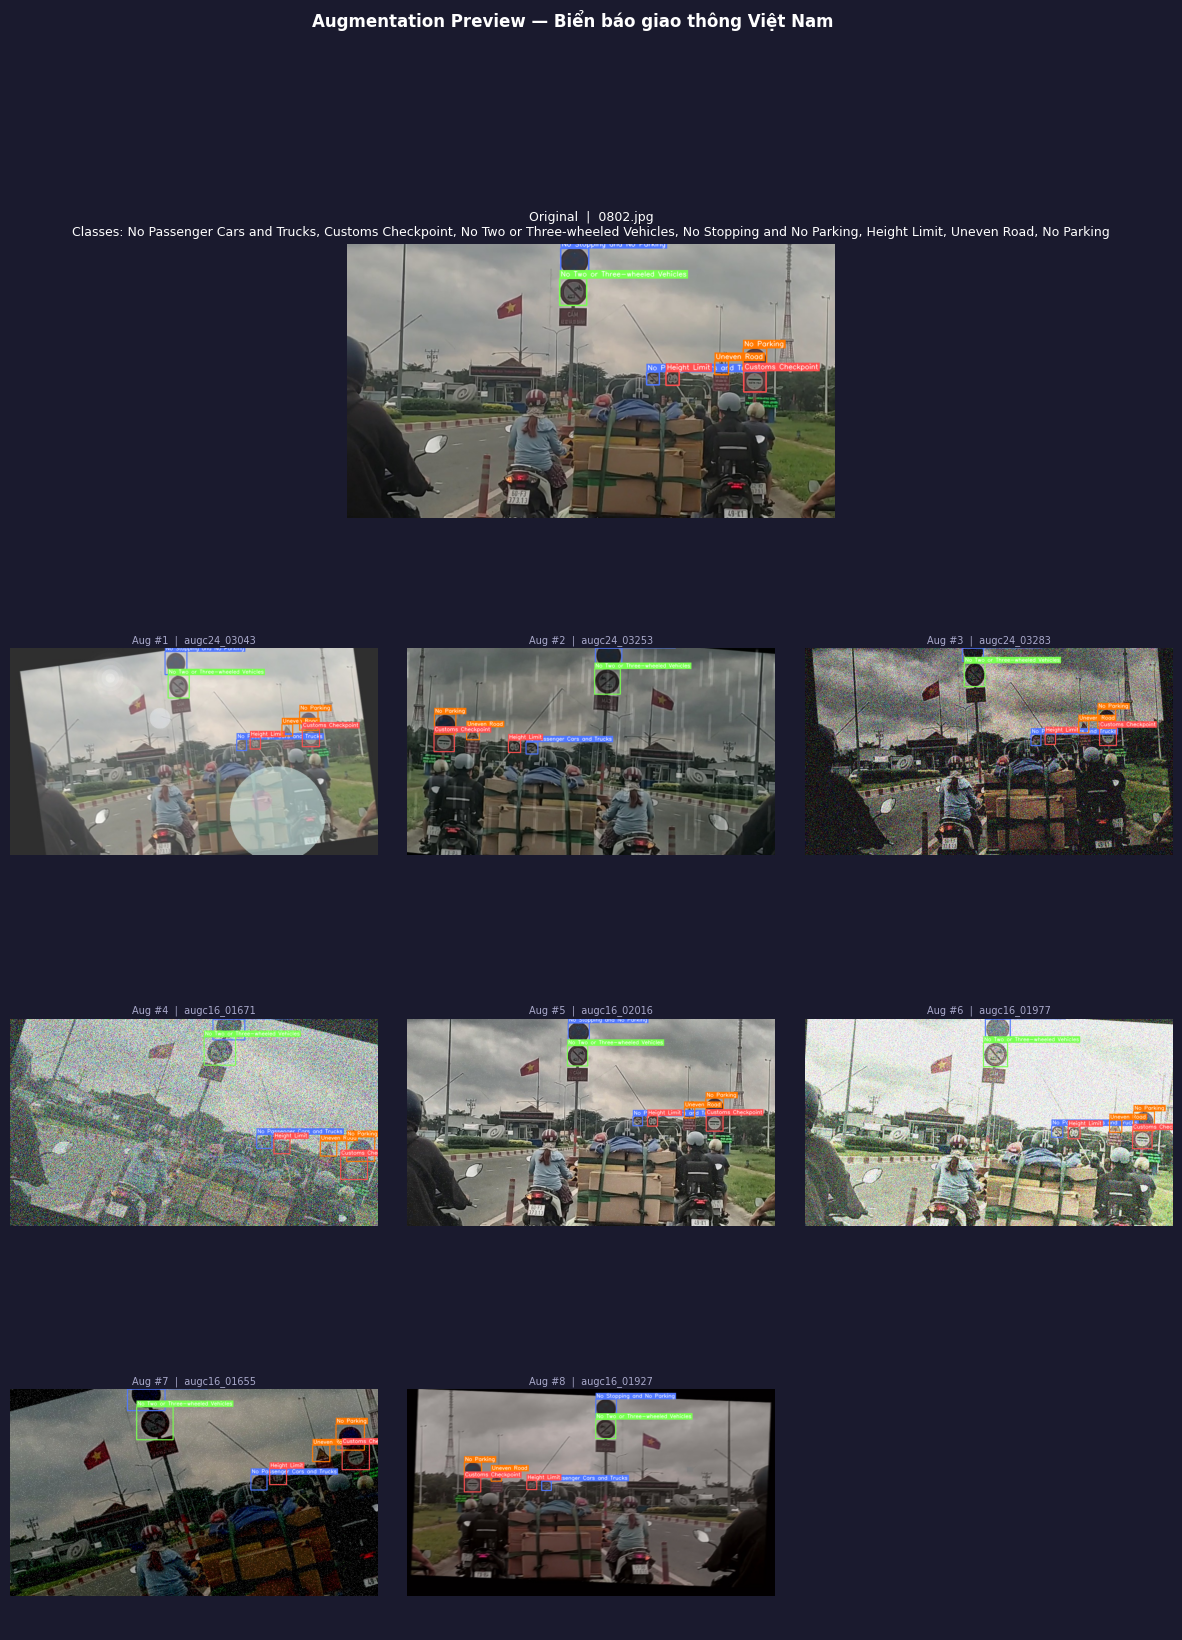

Đã lưu: /kaggle/working/aug_preview.png


In [111]:
import cv2, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ─────────────────────────────────────────────
DATASET_ROOT = "/kaggle/working/DoanAi_aug"
CLASSES_FILE = DATASET_ROOT + "/classes_en.txt"
NUM_AUG_SHOW = 8
SEED         = None   # None = random mỗi lần
# ─────────────────────────────────────────────

if SEED is not None:
    random.seed(SEED)

IMAGES_DIR = Path(DATASET_ROOT) / "images"
LABELS_DIR = Path(DATASET_ROOT) / "labels"

with open(CLASSES_FILE) as f:
    CLASS_NAMES = [l.strip() for l in f if l.strip()]

# ── Đọc label ────────────────────────────────────────────────
def read_label(lbl_path):
    rows = []
    p = Path(lbl_path)
    if not p.exists():
        return rows
    for line in p.read_text().strip().splitlines():
        parts = line.strip().split()
        if len(parts) == 5:
            try:
                rows.append([int(float(parts[0]))] + list(map(float, parts[1:])))
            except ValueError:
                continue
    return rows

# ── Vẽ bbox ───────────────────────────────────────────────────
COLORS = [
    (255,80,80),(80,180,80),(80,120,255),(255,180,0),
    (180,80,255),(0,200,200),(255,120,0),(120,255,80),
]

def draw_boxes(img_rgb, labels):
    img = img_rgb.copy()
    h, w = img.shape[:2]
    for row in labels:
        cls = int(row[0])
        cx, cy, bw, bh = row[1], row[2], row[3], row[4]
        x1 = int((cx - bw/2)*w); y1 = int((cy - bh/2)*h)
        x2 = int((cx + bw/2)*w); y2 = int((cy + bh/2)*h)
        color = COLORS[cls % len(COLORS)]
        cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
        label = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else str(cls)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(img, (x1, y1-th-6), (x1+tw+4, y1), color, -1)
        cv2.putText(img, label, (x1+2, y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,255), 1, cv2.LINE_AA)
    return img

# ── Chọn ảnh gốc có ảnh aug trong dataset ────────────────────
# Tìm tất cả stem của ảnh aug: có dạng {stem_goc}_augc{cls}_{idx}
all_imgs = sorted(IMAGES_DIR.glob("*.jpg")) + \
           sorted(IMAGES_DIR.glob("*.jpeg")) + \
           sorted(IMAGES_DIR.glob("*.png"))

# Tách riêng ảnh gốc và ảnh aug
original_stems = {p.stem for p in all_imgs if "_augc" not in p.stem}
aug_imgs_all   = [p for p in all_imgs if "_augc" in p.stem]

# Với mỗi ảnh aug, tìm stem gốc (phần trước "_augc")
from collections import defaultdict
stem_to_augs = defaultdict(list)
for aug_path in aug_imgs_all:
    # stem dạng: {original_stem}_augc{cls}_{idx:05d}
    parts = aug_path.stem.split("_augc")
    orig_stem = parts[0]
    if orig_stem in original_stems:
        stem_to_augs[orig_stem].append(aug_path)

# Chỉ chọn ảnh gốc có ít nhất 1 ảnh aug
candidates = [s for s in stem_to_augs if len(stem_to_augs[s]) > 0]
print(f"Tổng ảnh gốc có aug trong dataset: {len(candidates)}")

chosen_stem = random.choice(candidates)
chosen_orig = IMAGES_DIR / next(
    p.name for p in all_imgs if p.stem == chosen_stem
)

# Lấy tối đa NUM_AUG_SHOW ảnh aug của ảnh này
aug_paths = stem_to_augs[chosen_stem]
random.shuffle(aug_paths)
aug_paths = aug_paths[:NUM_AUG_SHOW]

# ── Load ảnh gốc + aug ───────────────────────────────────────
def load(path):
    img = cv2.imread(str(path))
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

orig_img    = load(chosen_orig)
orig_labels = read_label(LABELS_DIR / (chosen_stem + ".txt"))
class_names_shown = list({CLASS_NAMES[r[0]] for r in orig_labels if r[0] < len(CLASS_NAMES)})

print(f"Ảnh gốc  : {chosen_orig.name}")
print(f"Classes  : {class_names_shown}")
print(f"Số aug   : {len(aug_paths)}")

# ── Vẽ grid ──────────────────────────────────────────────────
ncols = 3
nrows = 1 + (len(aug_paths) + ncols - 1) // ncols
fig   = plt.figure(figsize=(5*ncols, 4.5*nrows), facecolor="#1a1a2e")
gs    = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=0.35, wspace=0.08)

# Hàng 0: ảnh gốc full width
ax0 = fig.add_subplot(gs[0, :])
ax0.imshow(draw_boxes(orig_img, orig_labels))
ax0.set_title(
    f"Original  |  {chosen_orig.name}\n"
    f"Classes: {', '.join(class_names_shown)}",
    color="white", fontsize=9, pad=6
)
ax0.axis("off")
for spine in ax0.spines.values():
    spine.set_edgecolor("#4a4a8a"); spine.set_linewidth(1.5)

# Các hàng sau: ảnh aug đã có trong dataset
for idx, aug_path in enumerate(aug_paths):
    row = 1 + idx // ncols
    col = idx % ncols
    ax  = fig.add_subplot(gs[row, col])
    aug_img    = load(aug_path)
    aug_labels = read_label(LABELS_DIR / (aug_path.stem + ".txt"))
    ax.imshow(draw_boxes(aug_img, aug_labels))
    ax.set_title(f"Aug #{idx+1}  |  {aug_path.stem[-12:]}",
                 color="#aaaacc", fontsize=7, pad=4)
    ax.axis("off")

# Ẩn ô trống
for empty in range(len(aug_paths), (nrows-1)*ncols):
    fig.add_subplot(gs[1 + empty//ncols, empty%ncols]).axis("off")

fig.suptitle("Augmentation Preview — Biển báo giao thông Việt Nam",
             color="white", fontsize=12, fontweight="bold", y=1.01)
plt.savefig("/kaggle/working/aug_preview.png",
            bbox_inches="tight", dpi=130, facecolor=fig.get_facecolor())
plt.show()
print("Đã lưu: /kaggle/working/aug_preview.png")